# ДЗ 7. Классификация гиперспектральных изображений с помощью VSSD

Датасет: [WHU-Hi-HongHu](https://huggingface.co/datasets/danaroth/whu_hi) - гиперспектральная съёмка с БПЛА, сцена 940×475 пикселей, 270 спектральных каналов

Задача: попиксельная классификация (по небольшому участку вокруг пикселя определить его культуру)

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

pip_install("datasets", "huggingface_hub", "spectral", "scikit-learn", "matplotlib", "pandas")

In [2]:
import os
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn, Tensor
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from huggingface_hub import hf_hub_download
from datasets import Dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [4]:
PATCH_SIZE = 11
N_PCA = 30
TRAIN_FRAC = 0.10
VAL_FRAC = 0.10
BATCH_SIZE = 128
NUM_EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-2
EMBED_DIM = 64

SMOKE_TEST = False
if SMOKE_TEST:
    NUM_EPOCHS = 2
    SUBSAMPLE = 8000
else:
    SUBSAMPLE = None

## 1. Загрузка и подготовка данных

In [5]:
REPO = "danaroth/whu_hi"
SCENE = "WHU-Hi-HongHu"

img_bsq = hf_hub_download(REPO, f"{SCENE}/{SCENE}.bsq", repo_type="dataset")
img_hdr = hf_hub_download(REPO, f"{SCENE}/{SCENE}.hdr", repo_type="dataset")
gt_bsq = hf_hub_download(REPO, f"{SCENE}/{SCENE}_gt.bsq", repo_type="dataset")
gt_hdr = hf_hub_download(REPO, f"{SCENE}/{SCENE}_gt.hdr", repo_type="dataset")
print("Файлы загружены в кэш HF.")

WHU-Hi-HongHu/WHU-Hi-HongHu.bsq:   0%|          | 0.00/482M [00:00<?, ?B/s]

WHU-Hi-HongHu/WHU-Hi-HongHu.hdr:   0%|          | 0.00/3.67k [00:00<?, ?B/s]

WHU-Hi-HongHu/WHU-Hi-HongHu_gt.bsq:   0%|          | 0.00/446k [00:00<?, ?B/s]

WHU-Hi-HongHu/WHU-Hi-HongHu_gt.hdr:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

Файлы загружены в кэш HF.


In [6]:
import spectral.io.envi as envi

img = np.array(envi.open(img_hdr, img_bsq).load(), dtype=np.float32)
gt = np.array(envi.open(gt_hdr, gt_bsq).load()).squeeze().astype(np.int64)

H, W, N_BANDS = img.shape
NUM_CLASSES = int(gt.max())

In [7]:
CLASS_NAMES = [
    "Red roof", "Road", "Bare soil", "Cotton", "Cotton firewood",
    "Rape", "Chinese cabbage", "Pakchoi", "Cabbage", "Tuber mustard",
    "Brassica parachinensis", "Brassica chinensis", "Small Brassica chinensis",
    "Lactuca sativa", "Celtuce", "Film covered lettuce", "Romaine lettuce",
    "Carrot", "White radish", "Garlic sprout", "Broad bean", "Tree",
]
assert len(CLASS_NAMES) == NUM_CLASSES

Стандартизация по каналам и понижение размерности PCA: 270 → 30 компонент.

In [8]:
flat = img.reshape(-1, N_BANDS)
flat_std = StandardScaler().fit_transform(flat)

pca = PCA(n_components=N_PCA, random_state=SEED)
flat_pca = pca.fit_transform(flat_std)
print(f"Сохранённая дисперсия PCA: {pca.explained_variance_ratio_.sum():.4f}")

X = flat_pca.reshape(H, W, N_PCA).astype(np.float32)

Сохранённая дисперсия PCA: 0.9930


Как видно, мы сохранили 0.99% диспрерсии

In [9]:
MARGIN = PATCH_SIZE // 2
X_PAD = torch.from_numpy(
    np.pad(X, ((MARGIN, MARGIN), (MARGIN, MARGIN), (0, 0)), mode="reflect")
)

rows, cols = np.where(gt > 0)
labels = gt[rows, cols] - 1

coords = Dataset.from_dict({
    "row": rows.astype(np.int64),
    "col": cols.astype(np.int64),
    "label": labels.astype(np.int64),
})
coords = coords.class_encode_column("label")

if SUBSAMPLE is not None:
    coords = coords.shuffle(seed=SEED).select(range(SUBSAMPLE))

print(coords)

Stringifying the column:   0%|          | 0/386693 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/386693 [00:00<?, ? examples/s]

Dataset({
    features: ['row', 'col', 'label'],
    num_rows: 386693
})


Стратифицированное разбиение train / val / test (по умолчанию 10% / 10% / 80%).

In [10]:
split1 = coords.train_test_split(
    test_size=1 - TRAIN_FRAC, seed=SEED, stratify_by_column="label"
)
train_ds = split1["train"]
rel_val = VAL_FRAC / (1 - TRAIN_FRAC)
split2 = split1["test"].train_test_split(
    test_size=1 - rel_val, seed=SEED, stratify_by_column="label"
)
val_ds, test_ds = split2["train"], split2["test"]
print(f"train={len(train_ds):,}  val={len(val_ds):,}  test={len(test_ds):,}")

train=38,669  val=38,669  test=309,355


In [11]:
def patch_collate(batch):
    xs, ys = [], []
    for ex in batch:
        r, c = ex["row"], ex["col"]
        patch = X_PAD[r:r + PATCH_SIZE, c:c + PATCH_SIZE, :]
        xs.append(patch.permute(2, 0, 1))
        ys.append(ex["label"])
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=patch_collate, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=patch_collate, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=patch_collate, num_workers=2)

xb, yb = next(iter(train_loader))
print(f"Батч: x={tuple(xb.shape)}  y={tuple(yb.shape)}")

Батч: x=(128, 30, 11, 11)  y=(128,)


## 2. Модели


### A) VSSD

In [12]:
class PatchEmbed(nn.Module):

    def __init__(self, in_chans: int, dim: int):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, dim, kernel_size=3, stride=1, padding=1)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x: Tensor):
        x = self.proj(x)
        B, D, Hh, Ww = x.shape
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), (Hh, Ww)


class NonCausalSSD(nn.Module):

    def __init__(self, dim: int, n_heads: int = 4, d_conv: int = 3, expand: int = 2):
        super().__init__()
        self.dim = dim
        self.d_inner = expand * dim
        self.n_heads = n_heads
        assert self.d_inner % n_heads == 0
        self.head_dim = self.d_inner // n_heads

        self.in_proj = nn.Linear(dim, 4 * self.d_inner, bias=False)
        self.conv2d = nn.Conv2d(
            self.d_inner, self.d_inner, kernel_size=d_conv,
            padding=(d_conv - 1) // 2, groups=self.d_inner, bias=True,
        )
        self.D = nn.Parameter(torch.ones(n_heads))
        self.out_proj = nn.Linear(self.d_inner, dim, bias=False)

    def _heads(self, t: Tensor) -> Tensor:
        B, L, _ = t.shape
        return t.view(B, L, self.n_heads, self.head_dim)

    def forward(self, x: Tensor, hw) -> Tensor:
        B, L, _ = x.shape
        Hh, Ww = hw
        xq = self.in_proj(x)
        v, k, q, z = xq.chunk(4, dim=-1)

        v_img = v.transpose(1, 2).reshape(B, self.d_inner, Hh, Ww)
        v_img = F.silu(self.conv2d(v_img))
        v = v_img.flatten(2).transpose(1, 2)

        v = self._heads(v); k = self._heads(k); q = self._heads(q)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum("blhd,blhe->bhde", k, v)
        k_sum = k.sum(dim=1)
        z_norm = 1.0 / (torch.einsum("blhd,bhd->blh", q, k_sum) + 1e-6)
        out = torch.einsum("blhd,bhde->blhe", q, kv) * z_norm.unsqueeze(-1)

        out = out + self.D.view(1, 1, -1, 1) * v
        out = out.reshape(B, L, self.d_inner)
        out = out * F.silu(z)
        return self.out_proj(out)


class Mlp(nn.Module):
    def __init__(self, dim: int, ratio: int = 4):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * ratio)
        self.fc2 = nn.Linear(dim * ratio, dim)

    def forward(self, x: Tensor) -> Tensor:
        return self.fc2(F.gelu(self.fc1(x)))


class VSSDBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int = 4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.mixer = NonCausalSSD(dim, n_heads=n_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim)

    def forward(self, x: Tensor, hw) -> Tensor:
        x = x + self.mixer(self.norm1(x), hw)
        x = x + self.mlp(self.norm2(x))
        return x


class VSSDClassifier(nn.Module):
    def __init__(self, in_chans: int, n_classes: int, dim: int = 64,
                 depth: int = 4, n_heads: int = 4):
        super().__init__()
        self.embed = PatchEmbed(in_chans, dim)
        self.blocks = nn.ModuleList([VSSDBlock(dim, n_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x: Tensor) -> Tensor:
        x, hw = self.embed(x)
        for blk in self.blocks:
            x = blk(x, hw)
        x = self.norm(x).mean(dim=1)
        return self.head(x)

### Обучение VSSD

In [13]:
@torch.no_grad()
def update_cm(cm, preds, labels):
    idx = labels * NUM_CLASSES + preds
    binc = torch.bincount(idx, minlength=NUM_CLASSES ** 2)
    cm += binc.reshape(NUM_CLASSES, NUM_CLASSES).cpu()


def metrics_from_cm(cm):
    cm = cm.float()
    total = cm.sum()
    oa = cm.diag().sum() / (total + 1e-8)

    recall = cm.diag() / (cm.sum(dim=1) + 1e-8)
    aa = recall.mean()
    precision = cm.diag() / (cm.sum(dim=0) + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    pe = (cm.sum(dim=0) * cm.sum(dim=1)).sum() / (total ** 2 + 1e-8)
    kappa = (oa - pe) / (1 - pe + 1e-8)

    return {
        "oa": oa.item(),
        "aa": aa.item(),
        "kappa": kappa.item(),
        "f1_macro": f1.mean().item(),
    }


def run_epoch(model, loader, criterion, device, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    total_loss, n = 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)
            update_cm(cm, logits.detach().argmax(1), y)

    m = metrics_from_cm(cm)
    m["loss"] = total_loss / n
    return m

In [14]:
def make_scheduler(optimizer, n_epochs, warmup=3):
    return SequentialLR(
        optimizer,
        schedulers=[
            LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup),
            CosineAnnealingLR(optimizer, T_max=n_epochs - warmup, eta_min=1e-6),
        ],
        milestones=[warmup],
    )


def train_model(model, name):
    model = model.to(device)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = make_scheduler(optimizer, NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{name}] параметров: {n_params:,}")

    best_metric, best_state = -1.0, None
    patience, patience_counter = 8, 0
    train_hist, val_hist = [], []
    t_start = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, criterion, device, optimizer)
        va = run_epoch(model, val_loader, criterion, device)
        scheduler.step()

        tr["epoch"] = va["epoch"] = epoch
        train_hist.append(tr); val_hist.append(va)

        print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
              f"train loss {tr['loss']:.4f} OA {tr['oa']:.4f} | "
              f"val loss {va['loss']:.4f} OA {va['oa']:.4f} AA {va['aa']:.4f} "
              f"k {va['kappa']:.4f} | {time.time() - t0:.1f}s")

        if va["oa"] > best_metric:
            best_metric = va["oa"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    train_time = time.time() - t_start
    return {
        "model": model, "name": name, "n_params": n_params,
        "train_time": train_time,
        "train_hist": pd.DataFrame(train_hist),
        "val_hist": pd.DataFrame(val_hist),
    }

In [15]:
vssd = VSSDClassifier(in_chans=N_PCA, n_classes=NUM_CLASSES,
                      dim=EMBED_DIM, depth=4, n_heads=4)
vssd_res = train_model(vssd, "VSSD")

[VSSD] параметров: 321,382
Epoch  1/50 | train loss 0.9854 OA 0.7676 | val loss 0.5293 OA 0.8807 AA 0.5982 k 0.8476 | 20.2s
Epoch  2/50 | train loss 0.2864 OA 0.9352 | val loss 0.1622 OA 0.9619 AA 0.8745 k 0.9518 | 16.8s
Epoch  3/50 | train loss 0.1193 OA 0.9696 | val loss 0.0843 OA 0.9769 AA 0.9232 k 0.9708 | 17.6s
Epoch  4/50 | train loss 0.0769 OA 0.9774 | val loss 0.0795 OA 0.9755 AA 0.9615 k 0.9690 | 17.7s
Epoch  5/50 | train loss 0.0449 OA 0.9869 | val loss 0.0426 OA 0.9869 AA 0.9692 k 0.9835 | 17.3s
Epoch  6/50 | train loss 0.0260 OA 0.9917 | val loss 0.0372 OA 0.9880 AA 0.9769 k 0.9849 | 19.2s
Epoch  7/50 | train loss 0.0223 OA 0.9935 | val loss 0.0314 OA 0.9900 AA 0.9838 k 0.9874 | 18.5s
Epoch  8/50 | train loss 0.0153 OA 0.9957 | val loss 0.0148 OA 0.9952 AA 0.9922 k 0.9939 | 18.7s
Epoch  9/50 | train loss 0.0142 OA 0.9961 | val loss 0.0241 OA 0.9921 AA 0.9808 k 0.9900 | 18.3s
Epoch 10/50 | train loss 0.0129 OA 0.9961 | val loss 0.0181 OA 0.9943 AA 0.9883 k 0.9928 | 18.5s
Epo

### B)  ViT

In [16]:
class ViTClassifier(nn.Module):
    def __init__(self, in_chans: int, n_classes: int, patch_size: int,
                 dim: int = 64, depth: int = 4, n_heads: int = 4):
        super().__init__()
        self.embed = PatchEmbed(in_chans, dim)
        n_tokens = patch_size * patch_size
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, n_tokens + 1, dim))
        nn.init.trunc_normal_(self.cls, std=0.02)
        nn.init.trunc_normal_(self.pos, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 4,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.embed(x)
        B = x.size(0)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))

In [17]:
vit = ViTClassifier(in_chans=N_PCA, n_classes=NUM_CLASSES,
                    patch_size=PATCH_SIZE, dim=EMBED_DIM, depth=4, n_heads=4)
vit_res = train_model(vit, "ViT")

[ViT] параметров: 226,838


/tmp/ipykernel_17861/2859502469.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth)


Epoch  1/50 | train loss 0.9273 OA 0.7851 | val loss 0.5019 OA 0.8846 AA 0.5890 k 0.8525 | 14.2s
Epoch  2/50 | train loss 0.3137 OA 0.9286 | val loss 0.1821 OA 0.9550 AA 0.8291 k 0.9430 | 14.4s
Epoch  3/50 | train loss 0.1448 OA 0.9613 | val loss 0.0996 OA 0.9696 AA 0.9034 k 0.9616 | 15.0s
Epoch  4/50 | train loss 0.0886 OA 0.9744 | val loss 0.0710 OA 0.9806 AA 0.9617 k 0.9755 | 14.4s
Epoch  5/50 | train loss 0.0569 OA 0.9827 | val loss 0.0551 OA 0.9851 AA 0.9651 k 0.9811 | 14.1s
Epoch  6/50 | train loss 0.0422 OA 0.9865 | val loss 0.0424 OA 0.9863 AA 0.9735 k 0.9827 | 15.9s
Epoch  7/50 | train loss 0.0364 OA 0.9891 | val loss 0.0258 OA 0.9925 AA 0.9869 k 0.9905 | 18.1s
Epoch  8/50 | train loss 0.0280 OA 0.9912 | val loss 0.0285 OA 0.9925 AA 0.9792 k 0.9905 | 18.5s
Epoch  9/50 | train loss 0.0216 OA 0.9935 | val loss 0.0296 OA 0.9914 AA 0.9806 k 0.9891 | 15.2s
Epoch 10/50 | train loss 0.0188 OA 0.9939 | val loss 0.0322 OA 0.9904 AA 0.9756 k 0.9879 | 14.2s
Epoch 11/50 | train loss 0.014

## 5. Оценка и визуализации

In [25]:

  enc_to_label = np.array([int(n) for n in coords.features["label"].names])
  enc_to_gt    = enc_to_label + 1
  CLASS_NAMES_ENC = [CLASS_NAMES[i] for i in enc_to_label]

In [18]:
def evaluate(model):
    criterion = nn.CrossEntropyLoss()
    return run_epoch(model, test_loader, criterion, device)


vssd_test = evaluate(vssd_res["model"])
vit_test = evaluate(vit_res["model"])
print("VSSD test:", {k: round(v, 4) for k, v in vssd_test.items()})
print("ViT  test:", {k: round(v, 4) for k, v in vit_test.items()})

VSSD test: {'oa': 0.9984, 'aa': 0.9962, 'kappa': 0.998, 'f1_macro': 0.9963, 'loss': 0.0052}
ViT  test: {'oa': 0.9984, 'aa': 0.9964, 'kappa': 0.998, 'f1_macro': 0.9961, 'loss': 0.0078}


### 5.1 Графики обучения

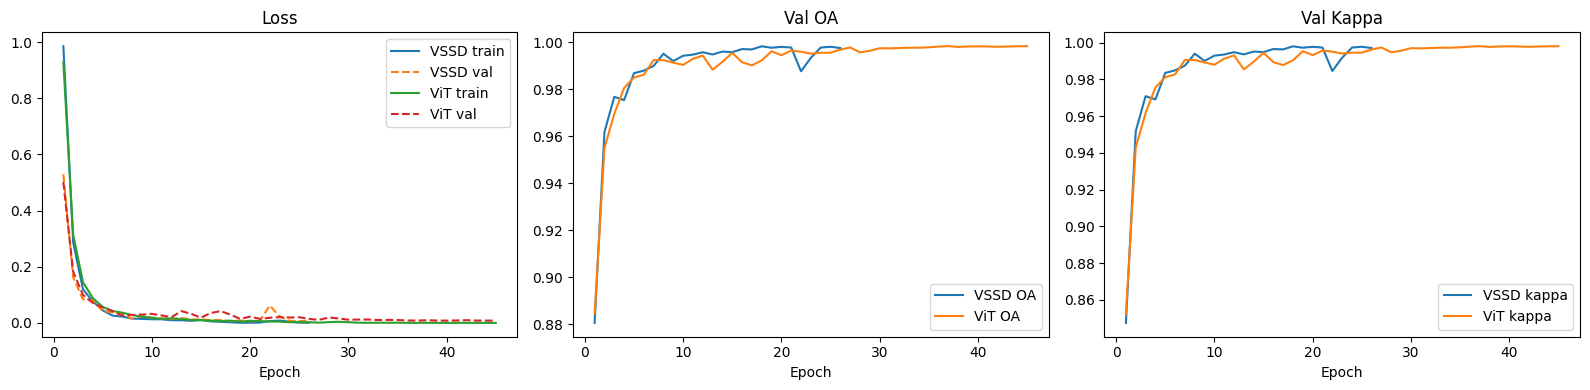

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for res in (vssd_res, vit_res):
    axes[0].plot(res["train_hist"].epoch, res["train_hist"].loss, label=f"{res['name']} train")
    axes[0].plot(res["val_hist"].epoch, res["val_hist"].loss, "--", label=f"{res['name']} val")
    axes[1].plot(res["val_hist"].epoch, res["val_hist"].oa, label=f"{res['name']} OA")
    axes[2].plot(res["val_hist"].epoch, res["val_hist"].kappa, label=f"{res['name']} kappa")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Val OA"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[2].set_title("Val Kappa"); axes[2].set_xlabel("Epoch"); axes[2].legend()
plt.tight_layout(); plt.show()

### 5.2 Карты классификации всей сцены

Прогоняем **все** размеченные пиксели через модель и раскрашиваем сцену 940×475 по предсказанному классу (фон = чёрный).

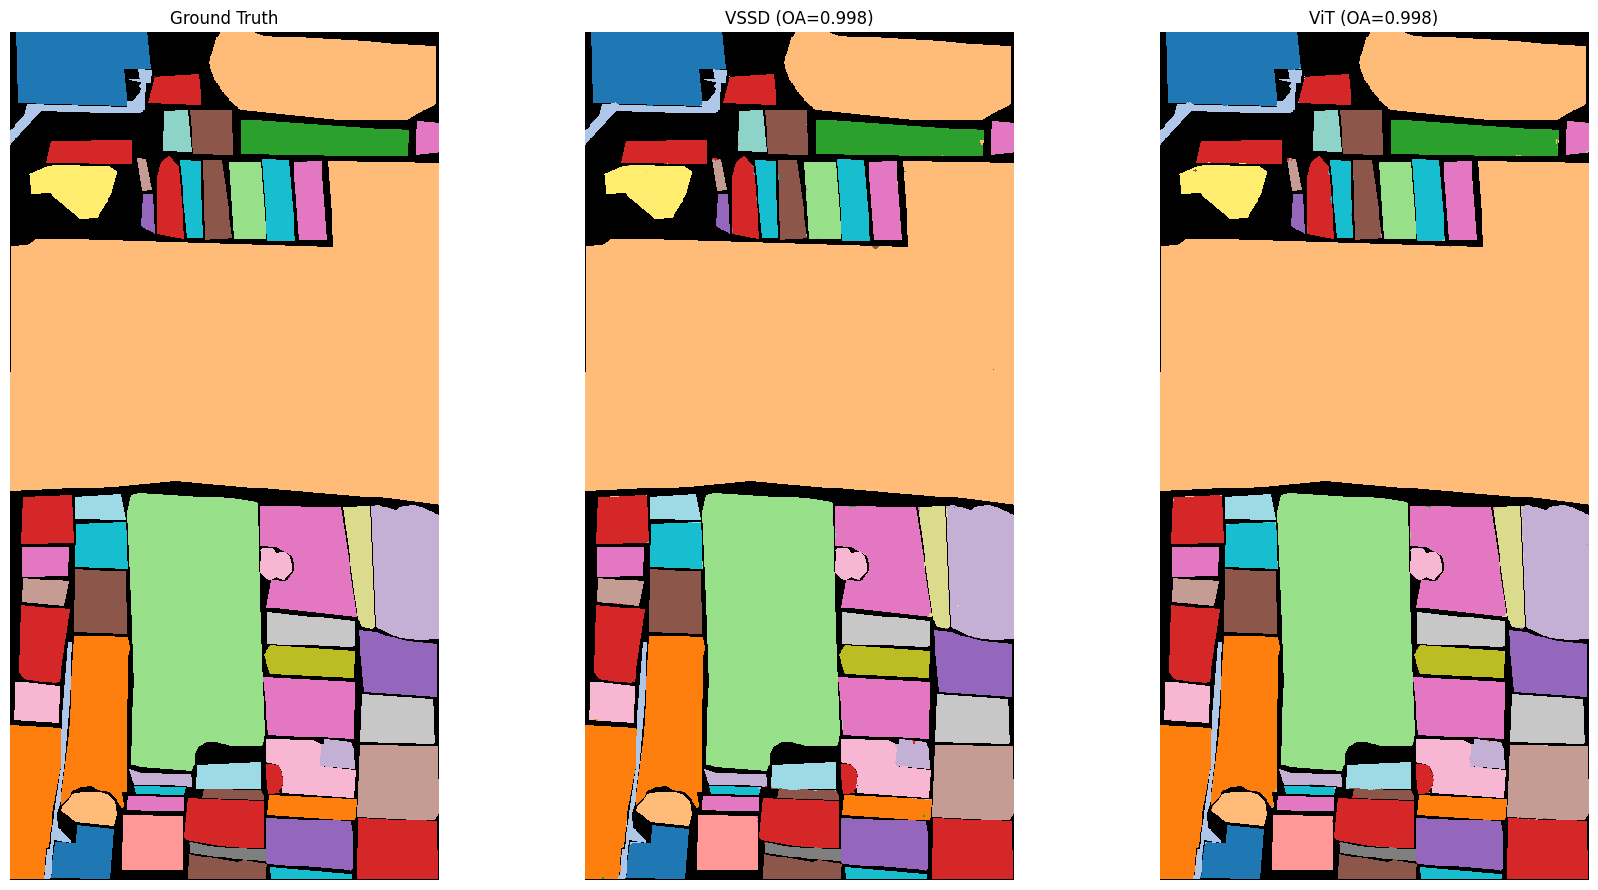

In [26]:

@torch.no_grad()
def predict_full_map(model):
    model.eval()
    pred_map = np.zeros((H, W), dtype=np.int64)        # 0 = фон
    r_all, c_all = np.where(gt > 0)
    for s in range(0, len(r_all), 4096):
        rs = r_all[s:s + 4096]; cs = c_all[s:s + 4096]
        batch = torch.stack([
            X_PAD[r:r + PATCH_SIZE, c:c + PATCH_SIZE, :].permute(2, 0, 1)
            for r, c in zip(rs, cs)
        ]).to(device)
        preds = model(batch).argmax(1).cpu().numpy()
        pred_map[rs, cs] = enc_to_gt[preds]            # encoded-id -> класс gt
    return pred_map


vssd_map = predict_full_map(vssd_res["model"])
vit_map = predict_full_map(vit_res["model"])

base = plt.cm.tab20(np.linspace(0, 1, 20))
extra = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES - 20)) if NUM_CLASSES > 20 else np.empty((0, 4))
palette = np.vstack([[0, 0, 0, 1], base[:min(20, NUM_CLASSES)], extra])
cmap = ListedColormap(palette)
norm = BoundaryNorm(np.arange(-0.5, NUM_CLASSES + 1.5), cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, data, title in zip(
    axes, [gt, vssd_map, vit_map],
    ["Ground Truth", f"VSSD (OA={vssd_test['oa']:.3f})", f"ViT (OA={vit_test['oa']:.3f})"],
):
    ax.imshow(data, cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

### 5.3 Матрицы ошибок (нормированные по строкам)

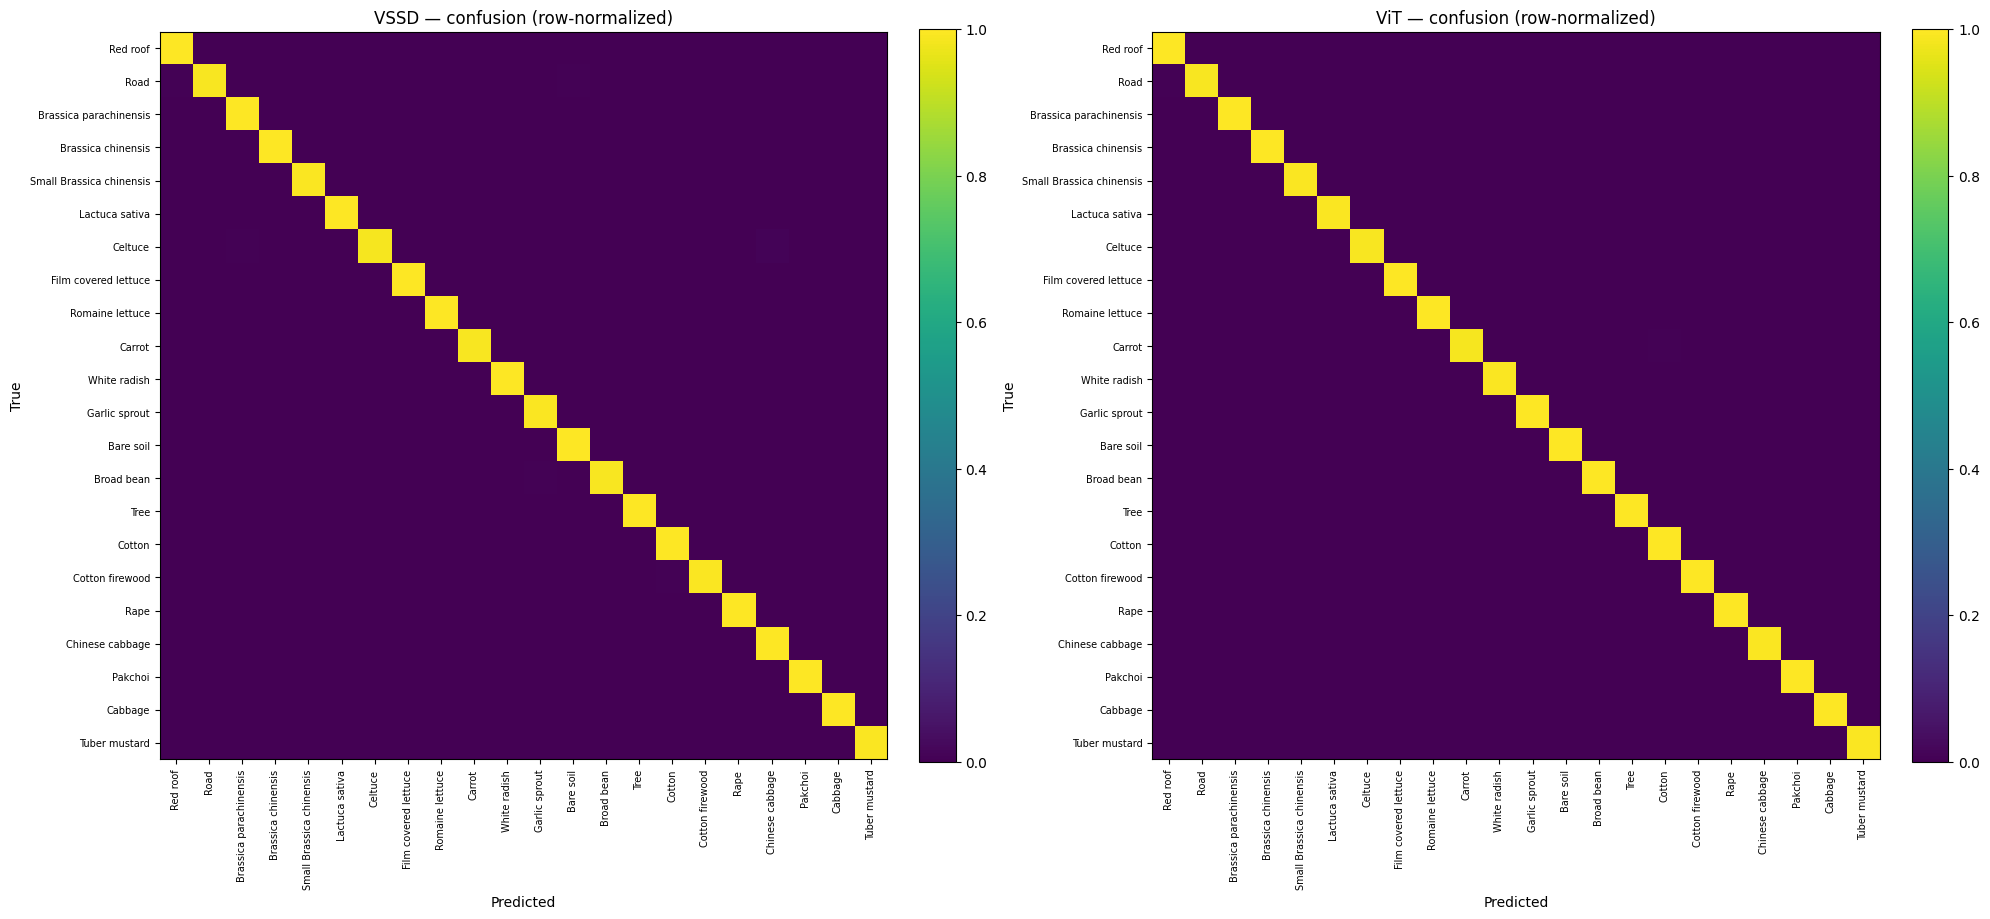

In [27]:
@torch.no_grad()
def confusion(model):
    model.eval()
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    for x, y in test_loader:
        x = x.to(device)
        update_cm(cm, model(x).argmax(1), y.to(device))
    return cm.numpy()


fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, model, name in zip(axes, [vssd_res["model"], vit_res["model"]], ["VSSD", "ViT"]):
    cm = confusion(model).astype(float)
    cm_norm = cm / (cm.sum(1, keepdims=True) + 1e-8)
    im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{name} — confusion (row-normalized)")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES_ENC, rotation=90, fontsize=7)
    ax.set_yticklabels(CLASS_NAMES_ENC, fontsize=7)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

### 5.4 Точность по классам

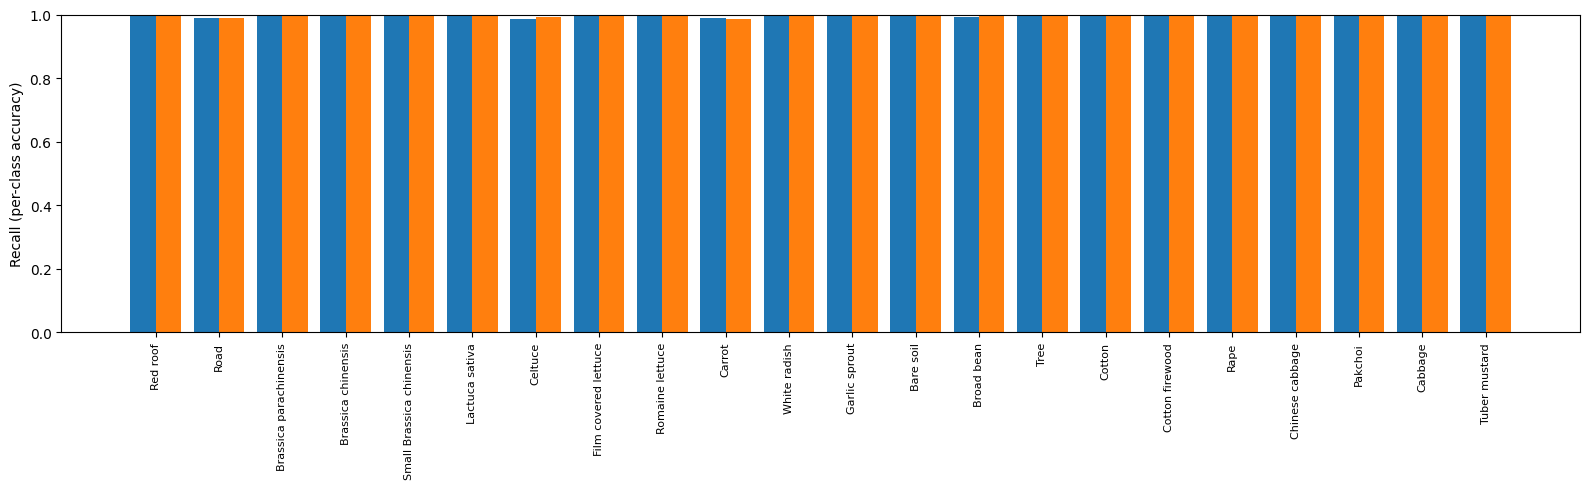

In [28]:
def per_class_recall(model):
    cm = confusion(model).astype(float)
    return cm.diagonal() / (cm.sum(1) + 1e-8)


vssd_pc = per_class_recall(vssd_res["model"])
vit_pc = per_class_recall(vit_res["model"])

x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - 0.2, vssd_pc, width=0.4, label="VSSD")
ax.bar(x + 0.2, vit_pc, width=0.4, label="ViT")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_ylabel("Recall (per-class accuracy)"); ax.set_ylim(0, 1)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES_ENC, rotation=90, fontsize=8)
plt.tight_layout(); plt.show()

### 5.6 Сводная таблица

In [24]:
summary = pd.DataFrame([
    {"model": "VSSD", **{k: vssd_test[k] for k in ["oa", "aa", "kappa", "f1_macro"]},
     "params": vssd_res["n_params"], "train_time_s": round(vssd_res["train_time"], 1)},
    {"model": "ViT", **{k: vit_test[k] for k in ["oa", "aa", "kappa", "f1_macro"]},
     "params": vit_res["n_params"], "train_time_s": round(vit_res["train_time"], 1)},
]).set_index("model")
summary[["oa", "aa", "kappa", "f1_macro"]] = summary[["oa", "aa", "kappa", "f1_macro"]].round(4)
summary

,oa,aa,kappa,f1_macro,params,train_time_s
model,,,,,,
VSSD,0.9984,0.9962,0.998,0.9963,321382,475.2
ViT,0.9984,0.9964,0.998,0.9961,226838,660.5


## 6. Выводы

Как видно модили имеют почти идентичную точность; Следовательно VSSD на уровн с трансформером;